# Comunicación Digital Avanzada (UNRC)
## Laboratorio N°1: Formateo de la Información y Ecualización del Histograma
### Marco Normativo y Estándar Satelital: DVB-S (ETSI EN 300 421)

---

### Contexto de Ingeniería y Objetivos
En los sistemas de comunicaciones satelitales y digitales modernos (tales como **DVB-S / DVB-S2**), la información proveniente de diversas fuentes (voz, telemetría, video o datos auxiliares) presenta redundancias estadísticas intrínsecas:
1. **Fuentes Discretas (Texto/Telemetría):** Presentan una fuerte asimetría en la distribución de símbolos (en código ASCII estándar de 8 bits, el bit más significativo suele ser sistemáticamente '0', induciendo un sesgo probabilístico y periodicidades marcadas cada byte).
2. **Fuentes Analógicas (Voz/Audio):** Muestran una distribución de amplitud fuertemente no uniforme (modelable mediante una distribución Laplaciana o Gamma), donde las pequeñas amplitudes tienen una probabilidad de ocurrencia sustancialmente mayor que los picos dinámicos.

#### El Desafío Físico en el Enlace Satelital
La transmisión directa de secuencias binarias no acondicionadas genera dos problemas críticos:
- **Pérdida de Sincronismo de Símbolo:** Largas rachas consecutivas de ceros o unos impiden la correcta recuperación de reloj (timing recovery) en el demodulador receptor (lazos de recuperación de fase y timing como Gardner o Mueller & Müller requieren transiciones frecuentes entre símbolos).
- **Concentración de Densidad Espectral de Potencia (PFD):** Las periodicidades de la fuente provocan líneas espectrales discretas de alta potencia. En enlaces satelitales, esto viola las normativas estrictas de la **ITU-R** sobre Densidad de Flujo de Potencia (*Power Flux Density - PFD*) en la superficie terrestre, aumentando el riesgo de interferencia perjudicial a enlaces terrenales adyacentes y causando intermodulación en el transpondedor (TWT/SSPA).

#### Objetivos del Laboratorio
1. **Formateo y Cuantificación Independiente:** Procesar en paralelo, sin multiplexar, un flujo de texto (ASCII 8 bits) y un flujo de audio (8 kHz, PCM con compresión no uniforme Ley-$\mu$, $\mu=255$).
2. **Caracterización de Información:** Computar las probabilidades empíricas $P(0), P(1)$, la Entropía de Shannon $H(X)$, rachas consecutivas y la función de autocorrelación polar NRZ.
3. **Dispersión de Energía (Scrambler DVB-S):** Implementar el aleatorizador PRBS basado en LFSR según la norma **ETSI EN 300 421** ($1 + X^{14} + X^{15}$), verificando el aplanamiento del histograma ($P(0) \approx P(1) \approx 0.5$) y la maximización de la entropía ($H(X) \to 1$ bit/bit).
4. **Descrambler y Reversibilidad Estricta:** Comprobar la recuperación íntegra de ambas secuencias ($BER = 0$) y la reconstrucción fiel de las señales originales.
5. **Exportación Modular para Laboratorio N°2:** Persistir las secuencias acondicionadas (`secuencia_audio_lab1.npy` y `secuencia_texto_lab1.npy`) junto con sus metadatos de ingeniería (`metadatos_lab1.json`).

In [1]:
# ==============================================================================
# CONFIGURACIÓN DE ENTORNO E IMPORTACIÓN DE DEPENDENCIAS
# ==============================================================================
import json
import os
from pathlib import Path
from typing import Any, Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import scipy.io.wavfile as wav
import scipy.signal as signal

# Configuración de estilo de visualización profesional para telecomunicaciones
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.autolayout'] = False

print("✔ Dependencias científicas cargadas correctamente (NumPy, SciPy, Matplotlib).")

✔ Dependencias científicas cargadas correctamente (NumPy, SciPy, Matplotlib).


---
### Módulo 1: Formateo de Fuente Discreta (Texto / Telemetría)

#### Fundamento Teórico
En el estándar DVB-S, además del flujo principal de transporte (MPEG-TS), suelen transmitirse canales auxiliares de señalización, control y telemetría de red. 

Una fuente discreta emite un alfabeto finito $\mathcal{A} = \{a_1, a_2, \dots, a_M\}$. En la codificación de caracteres estándar **ASCII de 8 bits**, cada carácter se mapea a un byte (octeto). Para la transmisión serial, se adopta convencionalmente el orden **MSB first** (Most Significant Bit first), de modo que el bit 7 (de mayor peso) precede en el tiempo al bit 0 (de menor peso).

Dado que los caracteres legibles del estándar ASCII utilizan típicamente valores en el rango decimal $[32, 126]$, el bit de mayor peso (bit 7) es sistemáticamente $0$. Esto introduce un fuerte desbalance probabilístico inicial:
$$P(0) > P(1), \quad H(X) < 1 \text{ bit/bit}$$

In [2]:
# ==============================================================================
# MÓDULO 1: FORMATEO DE FUENTE DISCRETA (TEXTO / TELEMETRÍA)
# ==============================================================================

def texto_a_bits(texto: str) -> np.ndarray:
    """Convierte una cadena de texto a un array unidimensional NumPy de bits.
    
    Aplica codificación ASCII de 8 bits por carácter con orden de transmisión
    MSB first (Most Significant Bit first).
    
    Args:
        texto: Cadena de caracteres a codificar.
        
    Returns:
        np.ndarray: Vector 1D de tipo uint8 conteniendo los bits (0s y 1s).
    """
    # Conversión a array de bytes ASCII
    bytes_data = texto.encode('ascii')
    uint8_data = np.frombuffer(bytes_data, dtype=np.uint8)
    
    # np.unpackbits descompone cada byte en 8 bits (MSB first por especificación)
    bits_array = np.unpackbits(uint8_data)
    return bits_array.astype(np.uint8)


def bits_a_texto(bits: np.ndarray) -> str:
    """Reconstruye la cadena de texto original a partir de un array de bits.
    
    Agrupa los bits de a 8 (MSB first) y decodifica la representación ASCII.
    
    Args:
        bits: Vector 1D de bits con longitud múltiplo de 8.
        
    Returns:
        str: Cadena de texto decodificada.
    """
    if len(bits) % 8 != 0:
        raise ValueError(f"La secuencia de bits debe ser múltiplo de 8 (obtenido: {len(bits)}).")
    
    # np.packbits empaqueta bloques de 8 bits en enteros uint8
    bytes_data = np.packbits(bits).tobytes()
    return bytes_data.decode('ascii')


# --- Ejecución del Módulo 1 con Mensaje de Prueba ---
mensaje_prueba = "Hola, este es un test de comunicacion"
bits_texto = texto_a_bits(mensaje_prueba)

print(f"Texto original: '{mensaje_prueba}'")
print(f"Longitud en caracteres: {len(mensaje_prueba)} caracteres")
print(f"Longitud en bits: {len(bits_texto)} bits ({len(bits_texto)//8} bytes)")
print(f"Primeros 24 bits (primeros 3 caracteres MSB-first): {bits_texto[:24]}")

# Verificación de consistencia local
texto_reconstruido_test = bits_a_texto(bits_texto)
assert mensaje_prueba == texto_reconstruido_test, "Error en la reversibilidad del codificador de texto."
print("✔ Reversibilidad local de texto verificada con éxito.")

Texto original: 'Hola, este es un test de comunicacion'
Longitud en caracteres: 37 caracteres
Longitud en bits: 296 bits (37 bytes)
Primeros 24 bits (primeros 3 caracteres MSB-first): [0 1 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 1 1 0 1 1 0 0]
✔ Reversibilidad local de texto verificada con éxito.


---
### Módulo 2: Formateo de Fuente Analógica (Audio - Muestreo y Cuantificación PCM)

#### 1. Teorema de Muestreo de Nyquist-Shannon
Para una señal analógica continua en tiempo $x(t)$ de banda limitada con frecuencia máxima $f_{max} = 4\text{ kHz}$ (ancho de banda telefónico estándar de voz), la tasa de muestreo mínima requerida para evitar aliasing espectral es:
$$F_s \ge 2 f_{max} = 8000\text{ muestras/segundo}$$
El período de muestreo resultante es $T_s = 1/F_s = 125\;\mu\text{s}$.

#### 2. Compresión No Uniforme (Companding): Ley-$\mu$
Las señales de voz y audio no poseen una distribución uniforme de amplitudes; por el contrario, presentan una **distribución Laplaciana** (o Gamma), donde la probabilidad acumulada de amplitudes muy bajas ($|x| \ll x_{max}$) es extremadamente alta, y las grandes excursiones de amplitud ocurren con poca frecuencia.

Si se utiliza una cuantificación uniforme lineal, el error relativo (y la relación señal a ruido de cuantificación, **SQNR**) degrada severamente para señales débiles, ya que el paso de cuantificación $\Delta$ es constante e independiente de la amplitud instantánea.

Para contrarrestar esto, los estándares de telecomunicaciones ITU-T (como el estándar telefónico G.711) emplean **compansión no uniforme**. En América y Japón se adopta la **Ley-$\mu$** ($\\mu = 255$):

$$y = F(x) = \text{sgn}(x) \frac{\ln(1 + \mu |x|)}{\ln(1 + \mu)}, \quad -1 \le x \le 1$$

Donde:
- Para amplitudes pequeñas ($|x| \to 0$), la pendiente es elevada: $\frac{dy}{dx}\Big|_{x=0} = \frac{\mu}{\ln(1 + \mu)} \approx \frac{255}{\ln(256)} \approx 46$, aumentando fuertemente la resolución efectiva (pasos de cuantificación muy finos).
- Para amplitudes grandes ($|x| \to 1$), la curva se comprime logarítmicamente.

El resultado es una relación **SQNR prácticamente constante** a lo largo de un rango dinámico de más de 40 dB.

#### 3. Expansión Inversa (Reconstrucción):
$$x = F^{-1}(y) = \text{sgn}(y) \frac{(1 + \mu)^{|y|} - 1}{\mu}, \quad -1 \le y \le 1$$

#### 4. Cuantificación Uniforme Midrise y Codificación Binaria Natural
Sobre la señal comprimida $y \in [-1, 1]$, se aplica una cuantificación en $L = 2^k$ niveles midrise simétricos:
$$\Delta = \frac{2}{L}$$
$$\text{índice} = \text{clip}\left(\left\lfloor \frac{y + 1}{\Delta} \right\rfloor, 0, L - 1\right)$$
Cada índice entero se mapea en un código binario natural de $k$ bits (MSB first).

In [3]:
# ==============================================================================
# MÓDULO 2: FORMATEO DE FUENTE ANALÓGICA (AUDIO - MUESTREO Y CUANTIFICACIÓN PCM)
# ==============================================================================

def ley_mu_compresion(x: np.ndarray, mu: float = 255.0) -> np.ndarray:
    """Aplica la función de compresión logarítmica Ley-µ normalizada sobre [-1, 1]."""
    x_clip = np.clip(x, -1.0, 1.0)
    return np.sign(x_clip) * np.log(1.0 + mu * np.abs(x_clip)) / np.log(1.0 + mu)


def ley_mu_expansion(y: np.ndarray, mu: float = 255.0) -> np.ndarray:
    """Aplica la función de expansión inversa Ley-µ para decodificación analógica."""
    y_clip = np.clip(y, -1.0, 1.0)
    return np.sign(y_clip) * ((1.0 + mu) ** np.abs(y_clip) - 1.0) / mu


def cuantificar_pcm(
    signal_in: np.ndarray, 
    k_bits: int = 6, 
    usar_ley_mu: bool = True, 
    mu: float = 255.0
) -> Tuple[np.ndarray, np.ndarray, float]:
    """Muestrea y cuantifica una señal analógica normalizada en [-1, 1] usando PCM.
    
    Args:
        signal_in: Array de muestras analógicas normalizadas en [-1, 1].
        k_bits: Número de bits por muestra (L = 2^k niveles). Configurable (ej. 4, 6, 8).
        usar_ley_mu: Si True, aplica compresión Ley-µ previa a la cuantificación.
        mu: Parámetro de compansión (estándar telefónico = 255).
        
    Returns:
        Tuple[np.ndarray, np.ndarray, float]:
            - bits_pcm: Flujo binario 1D (uint8) con las muestras codificadas.
            - signal_q: Señal analógica cuantificada en el dominio original [-1, 1].
            - delta: Paso de cuantificación uniforme en el dominio comprimido.
    """
    L = 2 ** k_bits
    delta = 2.0 / L
    
    # 1. Compresión no lineal si aplica
    if usar_ley_mu:
        x_comp = ley_mu_compresion(signal_in, mu=mu)
    else:
        x_comp = np.clip(signal_in, -1.0, 1.0)
        
    # 2. Cuantificador Midrise Uniforme en [-1, 1]
    # Mapeo a índices enteros 0 .. L-1
    indices = np.floor((x_comp + 1.0) / delta).astype(int)
    indices = np.clip(indices, 0, L - 1)
    
    # 3. Codificación a binario natural de k bits (MSB first)
    if k_bits <= 8:
        uint8_idx = indices.astype(np.uint8)
        unpacked = np.unpackbits(uint8_idx).reshape(-1, 8)
        bits_pcm = unpacked[:, 8 - k_bits:].flatten()
    else:
        shift = np.arange(k_bits - 1, -1, -1)
        bits_pcm = ((indices[:, None] >> shift) & 1).astype(np.uint8).flatten()
        
    # 4. De-cuantificación para análisis de fidelidad
    y_q = -1.0 + (indices + 0.5) * delta
    if usar_ley_mu:
        signal_q = ley_mu_expansion(y_q, mu=mu)
    else:
        signal_q = y_q
        
    return bits_pcm, signal_q, delta


def decodificar_pcm(
    bits_pcm: np.ndarray, 
    k_bits: int = 6, 
    usar_ley_mu: bool = True, 
    mu: float = 255.0
) -> np.ndarray:
    """Decodifica una secuencia de bits PCM regenerando la señal analógica estimada.
    
    Args:
        bits_pcm: Vector 1D de bits recibidos.
        k_bits: Resolución en bits por muestra empleada en el transmisor.
        usar_ley_mu: Si True, aplica expansión inversa Ley-µ.
        mu: Parámetro de compresión.
        
    Returns:
        np.ndarray: Señal analógica estimada reconstruida.
    """
    L = 2 ** k_bits
    delta = 2.0 / L
    
    n_muestras = len(bits_pcm) // k_bits
    bits_matrix = bits_pcm[:n_muestras * k_bits].reshape(n_muestras, k_bits)
    
    # Reconstrucción de índices a partir de representación binaria (MSB first)
    powers = 2 ** np.arange(k_bits - 1, -1, -1)
    indices = np.dot(bits_matrix, powers)
    
    y_q = -1.0 + (indices + 0.5) * delta
    if usar_ley_mu:
        return ley_mu_expansion(y_q, mu=mu)
    else:
        return y_q


# --- Carga de Señal de Audio con Fallback Preventivo ---
audio_path = Path("audio_lab1.wav")
fs_esperada = 8000

try:
    fs_leida, data_raw = wav.read(str(audio_path))
    print(f"✔ Archivo local '{audio_path}' cargado correctamente.")
    print(f"  Frecuencia de muestreo: {fs_leida} Hz | Formato: {data_raw.dtype} | Muestras: {len(data_raw)}")
    
    # Si la señal fuese estéreo, convertir a mono promediando canales
    if data_raw.ndim > 1:
        data_raw = data_raw.mean(axis=1)
        
    # Normalización estricta al intervalo dinámico [-1.0, 1.0]
    if np.issubdtype(data_raw.dtype, np.integer):
        max_val = np.iinfo(data_raw.dtype).max
        audio_norm = data_raw.astype(np.float64) / max_val
    else:
        audio_norm = data_raw.astype(np.float64) / np.max(np.abs(data_raw))
        
    fs_audio = fs_leida
except FileNotFoundError:
    print(f"⚠ Archivo '{audio_path}' no encontrado. Generando señal sintética multisinusoidal de prueba...")
    fs_audio = fs_esperada
    duracion_s = 0.5
    t_synth = np.linspace(0, duracion_s, int(fs_audio * duracion_s), endpoint=False)
    # Suma de componentes armónicas representativas de formantes de voz (300 Hz, 1 kHz, 2.5 kHz)
    synth_signal = (
        0.50 * np.sin(2 * np.pi * 300 * t_synth) +
        0.35 * np.sin(2 * np.pi * 1000 * t_synth) +
        0.15 * np.sin(2 * np.pi * 2500 * t_synth)
    )
    audio_norm = synth_signal / np.max(np.abs(synth_signal))
    print("✔ Señal sintética de audio generada exitosamente.")

# --- Configuración del Cuantificador PCM ---
k_bits_pcm = 6  # Configurable: ensayable con k=4 (L=16), k=6 (L=64), k=8 (L=256)
L_niveles = 2 ** k_bits_pcm
usar_compandor_mu = True

bits_audio, audio_cuantificado, delta_pcm = cuantificar_pcm(
    audio_norm, 
    k_bits=k_bits_pcm, 
    usar_ley_mu=usar_compandor_mu, 
    mu=255.0
)

# Cálculo de la Relación Señal a Ruido de Cuantificación (SQNR)
ruido_cuantificacion = audio_norm - audio_cuantificado
potencia_senal = np.mean(audio_norm ** 2)
potencia_ruido = np.mean(ruido_cuantificacion ** 2)
sqnr_db = 10 * np.log10(potencia_senal / potencia_ruido) if potencia_ruido > 0 else float('inf')

print(f"Parámetros de Cuantificación PCM:")
print(f"  Resolución: k = {k_bits_pcm} bits/muestra -> L = {L_niveles} niveles.")
print(f"  Paso de cuantificación (dominio comprimido): Δ = {delta_pcm:.5f}")
print(f"  Compansión: Ley-µ (µ = 255.0) -> {'ACTIVADA' if usar_compandor_mu else 'DESACTIVADA'}")
print(f"  Longitud del flujo binario resultante: {len(bits_audio)} bits")
print(f"  SQNR Empírico medido: {sqnr_db:.2f} dB")

✔ Archivo local 'audio_lab1.wav' cargado correctamente.
  Frecuencia de muestreo: 8000 Hz | Formato: int16 | Muestras: 50573
Parámetros de Cuantificación PCM:
  Resolución: k = 6 bits/muestra -> L = 64 niveles.
  Paso de cuantificación (dominio comprimido): Δ = 0.03125
  Compansión: Ley-µ (µ = 255.0) -> ACTIVADA
  Longitud del flujo binario resultante: 303438 bits
  SQNR Empírico medido: 25.90 dB


---
### Módulo 3: Caracterización Estadística Base (Función Universal)

#### 1. Entropía de Shannon
La entropía de una fuente binaria sin memoria modelada por la variable aleatoria $X \in \{0, 1\}$ mide el contenido medio de información o incertidumbre en **bit/bit**:
$$H(X) = - P(0) \log_2 P(0) - P(1) \log_2 P(1)$$
- La entropía es máxima ($H_{max} = 1.0$ bit/bit) si y solo si la fuente es **equiprobable**: $P(0) = P(1) = 0.5$.
- Si la fuente presenta sesgo ($P(0) \neq P(1)$), la entropía es estrictamente menor a 1, indicando la existencia de redundancia estadística compresible y predecible.

#### 2. Rachas Máximas Consecutivas (Run Length)
Una racha (*consecutive run*) es una secuencia ininterrumpida de símbolos idénticos ($000\dots$ o $111\dots$).
- En demoduladores coherentes, el sincronismo de símbolo depende de las transiciones de cruce por cero de la señal banda base.
- Rachas prolongadas de ceros o unos provocan que los filtros de lazo de recuperación de portadora y timing pierdan seguimiento, incrementando el jitter de fase y la probabilidad de error de bit (**BER**).

#### 3. Función de Autocorrelación Normalizada Polar NRZ
Para analizar la memoria temporal y las periodicidades ocultas de la secuencia de bits $b[n] \in \{0, 1\}$, se mapea a una señal binaria antipodal **polar NRZ**:
$$s[n] = 2 b[n] - 1 \in \{-1, +1\}$$
La función de autocorrelación determinística para un retardo (lag) $m$ se define como:
$$R_{ss}[m] = \frac{1}{N} \sum_{n=0}^{N-1-|m|} s[n] s[n+m]$$
- Para $m=0$, $R_{ss}[0] = 1.0$ (potencia media normalizada).
- Para secuencias de datos altamente correlacionadas (como caracteres de texto o muestras de audio), $R_{ss}[m]$ presenta lóbulos y picos secundarios significativos para retardos $m \neq 0$.
- Una fuente aleatoria pura (blanca) o idealmente ecualizada presenta:
$$R_{ss}[m] \approx \delta[m] = \begin{cases} 1 & m = 0 \\ 0 & m \neq 0 \end{cases}$$

In [4]:
# ==============================================================================
# MÓDULO 3: CARACTERIZACIÓN ESTADÍSTICA BASE (FUNCIÓN UNIVERSAL)
# ==============================================================================

def calcular_racha_maxima(bitstream: np.ndarray, valor: int) -> int:
    """Calcula la longitud máxima de rachas consecutivas de un símbolo (0 o 1).
    
    Implementación vectorizada O(N) eficiente basada en diferencias discretas.
    """
    es_simbolo = (bitstream == valor).astype(np.int8)
    if not np.any(es_simbolo):
        return 0
    
    d = np.diff(np.concatenate(([0], es_simbolo, [0])))
    inicios = np.where(d == 1)[0]
    fines = np.where(d == -1)[0]
    longitudes = fines - inicios
    return int(np.max(longitudes)) if len(longitudes) > 0 else 0


def calcular_autocorrelacion_nrz(
    bitstream: np.ndarray, 
    max_lags: int = 50
) -> Tuple[np.ndarray, np.ndarray]:
    """Calcula la función de autocorrelación normalizada en representación polar NRZ.
    
    Aplica transformación s[n] = 2*b[n] - 1 y calcula R_ss[m] mediante FFT
    utilizando scipy.signal.correlate para máxima eficiencia computacional.
    
    Args:
        bitstream: Vector 1D de bits (0s y 1s).
        max_lags: Rango de retardos ±m a retornar.
        
    Returns:
        Tuple[np.ndarray, np.ndarray]: Lags evaluados y coeficientes R_ss normalizados.
    """
    s_nrz = 2.0 * bitstream.astype(np.float64) - 1.0
    N = len(s_nrz)
    
    # Autocorrelación vía algoritmo FFT O(N log N)
    corr_full = signal.correlate(s_nrz, s_nrz, mode='full', method='fft')
    lags_full = signal.correlation_lags(N, N, mode='full')
    
    # Normalización tal que R_ss[0] = 1.0
    corr_norm = corr_full / N
    
    # Ventana de retardos relevantes
    mascara = (lags_full >= -max_lags) & (lags_full <= max_lags)
    return lags_full[mascara], corr_norm[mascara]


def evaluar_estadisticas(bitstream: np.ndarray, nombre_fuente: str = "Bitstream") -> Dict[str, Any]:
    """Evalúa integralmente las propiedades estadísticas y de información de un flujo binario.
    
    Args:
        bitstream: Array 1D de bits a evaluar.
        nombre_fuente: Etiqueta descriptiva para reporte.
        
    Returns:
        Dict[str, Any]: Diccionario con métricas empíricas calculadas.
    """
    N = len(bitstream)
    if N == 0:
        raise ValueError("El bitstream no puede ser de longitud cero.")
        
    n_ceros = int(np.sum(bitstream == 0))
    n_unos = int(np.sum(bitstream == 1))
    p0 = n_ceros / N
    p1 = n_unos / N
    
    # Entropía de Shannon H(X) en bit/bit
    h0 = -p0 * np.log2(p0) if p0 > 0 else 0.0
    h1 = -p1 * np.log2(p1) if p1 > 0 else 0.0
    H = h0 + h1
    
    racha_0 = calcular_racha_maxima(bitstream, 0)
    racha_1 = calcular_racha_maxima(bitstream, 1)
    
    lags, autocorr = calcular_autocorrelacion_nrz(bitstream, max_lags=50)
    
    resultado = {
        "fuente": nombre_fuente,
        "N_bits": N,
        "P(0)": p0,
        "P(1)": p1,
        "H(X)": H,
        "racha_max_0": racha_0,
        "racha_max_1": racha_1,
        "lags": lags,
        "autocorr": autocorr
    }
    return resultado


# --- Evaluación Estadística en Bruto de Ambas Fuentes ---
stats_texto_raw = evaluar_estadisticas(bits_texto, "Texto (Raw)")
stats_audio_raw = evaluar_estadisticas(bits_audio, "Audio PCM (Raw)")

print("=" * 70)
print("CARACTERIZACIÓN ESTADÍSTICA DE FUENTES EN BRUTO (PRE-SCRAMBLER)")
print("=" * 70)
for st in [stats_texto_raw, stats_audio_raw]:
    print(f"Fuente: {st['fuente']}")
    print(f"  Longitud: {st['N_bits']} bits")
    print(f"  P(0): {st['P(0)']:.5f} | P(1): {st['P(1)']:.5f}")
    print(f"  Entropía H(X): {st['H(X)']:.5f} bit/bit (Máximo teórico: 1.0)")
    print(f"  Racha máxima ceros: {st['racha_max_0']} bits | Racha máxima unos: {st['racha_max_1']} bits")
    print("-" * 70)

CARACTERIZACIÓN ESTADÍSTICA DE FUENTES EN BRUTO (PRE-SCRAMBLER)
Fuente: Texto (Raw)
  Longitud: 296 bits
  P(0): 0.53041 | P(1): 0.46959
  Entropía H(X): 0.99733 bit/bit (Máximo teórico: 1.0)
  Racha máxima ceros: 6 bits | Racha máxima unos: 4 bits
----------------------------------------------------------------------
Fuente: Audio PCM (Raw)
  Longitud: 303438 bits
  P(0): 0.51752 | P(1): 0.48248
  Entropía H(X): 0.99911 bit/bit (Máximo teórico: 1.0)
  Racha máxima ceros: 7 bits | Racha máxima unos: 7 bits
----------------------------------------------------------------------


---
### Módulo 4: Acondicionamiento Estadístico / Scrambler LFSR (Norma DVB-S)

#### 1. Especificación Normativa ETSI EN 300 421
El estándar europeo de radiodifusión de televisión y datos por satélite **DVB-S** especifica en su sección de *Energy Dispersal* (Dispersión de Energía) que el flujo binario debe ser aleatorizado mediante una **Secuencia Binaria Pseudoaleatoria (PRBS)** generada por un registro de desplazamiento con realimentación lineal (**LFSR**).

#### 2. Polinomio Generador Primitivo y Semilla de Carga
- **Polinomio Generador:** Polinomio primitivo de orden 15:
$$P(x) = 1 + x^{14} + x^{15}$$
- **Registro LFSR:** Compuesto por 15 etapas ($D_1$ a $D_{15}$).
- **Ecuación de Realimentación:** El bit que ingresa a la primera etapa ($D_1$) en cada pulso de reloj es la suma módulo-2 (XOR) de las salidas de las etapas 14 y 15:
$$D_1 = D_{14} \oplus D_{15}$$
El bit PRBS de salida resultante que se combina con el flujo de información es precisamente $D_{14} \oplus D_{15}$.
- **Vector de Inicialización Oficial (Semilla):**
$$\text{Semilla} = [1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0] \quad (\text{representación hexadecimal: } 0x4A80)$$
- **Período Máximo:** Al ser $P(x)$ un polinomio primitivo, la secuencia generada es una secuencia de longitud máxima ($m$-sequence) con período:
$$N_{periodo} = 2^{15} - 1 = 32767\text{ bits}$$

#### 3. Dispersión de Energía y Operación XOR
La secuencia aleatorizada $c[n]$ se obtiene mediante la suma módulo-2 bit a bit:
$$c[n] = b[n] \oplus p[n]$$
Donde $b[n]$ es el bitstream de la fuente y $p[n]$ es la secuencia PRBS generada. Esta operación garantiza:
1. **Aplanamiento del Histograma:** $P(c[n]=0) \approx P(c[n]=1) \approx 0.5$.
2. **Supresión de Líneas Espectrales:** El espectro de la señal modulada se vuelve cuasi-gaussiano y continuo, satisfaciendo los límites de **PFD** de la ITU-R.
3. **Mantenimiento del Sincronismo:** Se garantiza una densidad controlada de transiciones entre niveles lógicos para el demodulador.

In [5]:
# ==============================================================================
# MÓDULO 4: ACONDICIONAMIENTO ESTADÍSTICO / SCRAMBLER LFSR (NORMA DVB-S)
# ==============================================================================

# Semilla de inicialización oficial de la norma ETSI EN 300 421 (15 bits)
SEMILLA_DVB_S: List[int] = [1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0]


def generar_secuencia_pn(longitud: int, semilla: List[int] = SEMILLA_DVB_S) -> np.ndarray:
    """Genera la secuencia pseudoaleatoria PRBS según la norma DVB-S (ETSI EN 300 421).
    
    Implementa el LFSR de 15 etapas con polinomio P(x) = 1 + X^14 + X^15.
    Período máximo: 2^15 - 1 = 32767 bits. Se repite periódicamente según la longitud requerida.
    
    Args:
        longitud: Cantidad de bits PRBS a generar.
        semilla: Vector inicial de 15 bits [D1, D2, ..., D15].
        
    Returns:
        np.ndarray: Vector 1D de tipo uint8 con la secuencia PRBS generada.
    """
    if len(semilla) != 15:
        raise ValueError(f"La semilla DVB-S debe poseer exactamente 15 bits (recibido: {len(semilla)}).")
        
    reg = list(semilla)
    pn_seq = np.empty(longitud, dtype=np.uint8)
    
    for i in range(longitud):
        # Etapas D14 y D15 (índices 13 y 14 en base cero)
        feedback = reg[13] ^ reg[14]
        pn_seq[i] = feedback
        
        # Desplazamiento del registro a la derecha: reg[0] recibe el feedback
        reg = [feedback] + reg[:-1]
        
    return pn_seq


def scrambler_dvb(bitstream: np.ndarray, semilla: List[int] = SEMILLA_DVB_S) -> np.ndarray:
    """Aplica aleatorización DVB-S mediante suma módulo-2 (XOR) con la secuencia PRBS."""
    pn = generar_secuencia_pn(len(bitstream), semilla)
    return (bitstream ^ pn).astype(np.uint8)


# --- Aplicación del Scrambler por separado sobre Texto y Audio ---
bits_texto_scrambled = scrambler_dvb(bits_texto, SEMILLA_DVB_S)
bits_audio_scrambled = scrambler_dvb(bits_audio, SEMILLA_DVB_S)

# Reevaluación de estadísticas post-scrambler
stats_texto_scr = evaluar_estadisticas(bits_texto_scrambled, "Texto (Scrambled DVB-S)")
stats_audio_scr = evaluar_estadisticas(bits_audio_scrambled, "Audio (Scrambled DVB-S)")

print("=" * 70)
print("CARACTERIZACIÓN ESTADÍSTICA POST-SCRAMBLER DVB-S")
print("=" * 70)
for st in [stats_texto_scr, stats_audio_scr]:
    print(f"Fuente: {st['fuente']}")
    print(f"  Longitud: {st['N_bits']} bits")
    print(f"  P(0): {st['P(0)']:.5f} | P(1): {st['P(1)']:.5f}")
    print(f"  Entropía H(X): {st['H(X)']:.5f} bit/bit")
    print(f"  Racha máxima ceros: {st['racha_max_0']} bits | Racha máxima unos: {st['racha_max_1']} bits")
    print("-" * 70)

CARACTERIZACIÓN ESTADÍSTICA POST-SCRAMBLER DVB-S
Fuente: Texto (Scrambled DVB-S)
  Longitud: 296 bits
  P(0): 0.47635 | P(1): 0.52365
  Entropía H(X): 0.99839 bit/bit
  Racha máxima ceros: 10 bits | Racha máxima unos: 9 bits
----------------------------------------------------------------------
Fuente: Audio (Scrambled DVB-S)
  Longitud: 303438 bits
  P(0): 0.50048 | P(1): 0.49952
  Entropía H(X): 1.00000 bit/bit
  Racha máxima ceros: 18 bits | Racha máxima unos: 17 bits
----------------------------------------------------------------------


---
### Módulo 5: Descrambler y Verificación de Reversibilidad Estricta ($BER = 0$)

#### Fundamento Matemático del Descrambler
La operación XOR es un operador autoinverso en el cuerpo de Galois de dos elementos $GF(2)$. Dado el bitstream transmitido $c[n] = b[n] \oplus p[n]$, si en el receptor se genera una secuencia PRBS $p[n]$ idéntica e intrínsecamente sincronizada con la del transmisor (misma semilla y mismo instante de inicialización):

$$\hat{b}[n] = c[n] \oplus p[n] = (b[n] \oplus p[n]) \oplus p[n] = b[n] \oplus (p[n] \oplus p[n]) = b[n] \oplus 0 = b[n]$$

Por lo tanto:
- El circuito descrambler es idéntico al circuito scrambler (auto-involutivo).
- En ausencia de ruido o errores de canal, la tasa de error de bit (**BER**) debe ser idénticamente cero:
$$BER = \frac{1}{N} \sum_{n=0}^{N-1} (b[n] \oplus \hat{b}[n]) = 0.0000$$

In [6]:
# ==============================================================================
# MÓDULO 5: DESCRAMBLER Y VERIFICACIÓN DE REVERSIBILIDAD (BER = 0)
# ==============================================================================

def descrambler_dvb(bitstream_scrambled: np.ndarray, semilla: List[int] = SEMILLA_DVB_S) -> np.ndarray:
    """Descrambler DVB-S: operación inversa sincronizada (XOR idéntico con la PRBS)."""
    return scrambler_dvb(bitstream_scrambled, semilla)


# --- Recuperación de Flujos Binarios en Recepción ---
bits_texto_rx = descrambler_dvb(bits_texto_scrambled, SEMILLA_DVB_S)
bits_audio_rx = descrambler_dvb(bits_audio_scrambled, SEMILLA_DVB_S)

# Cálculo de Bit Error Rate (BER)
errores_texto = int(np.sum(bits_texto_rx != bits_texto))
ber_texto = errores_texto / len(bits_texto)

errores_audio = int(np.sum(bits_audio_rx != bits_audio))
ber_audio = errores_audio / len(bits_audio)

# --- Comprobación Estricta con Assertions ---
assert np.array_equal(bits_texto_rx, bits_texto), "Falla crítica: BER de Texto > 0"
assert np.array_equal(bits_audio_rx, bits_audio), "Falla crítica: BER de Audio > 0"

# Reconstrucción de la información de usuario
texto_recuperado = bits_a_texto(bits_texto_rx)
audio_recuperado = decodificar_pcm(bits_audio_rx, k_bits=k_bits_pcm, usar_ley_mu=usar_compandor_mu, mu=255.0)

# Verificación de fidelidad de audio
error_reconstruccion_audio = np.max(np.abs(audio_cuantificado - audio_recuperado))
assert error_reconstruccion_audio < 1e-12, "Falla en la reconstrucción analógica de audio."

print("=" * 70)
print("VERIFICACIÓN DE REVERSIBILIDAD Y FIDELIDAD EN RECEPCIÓN")
print("=" * 70)
print(f"✔ BER Canal Texto: {ber_texto:.8f} (Errores: {errores_texto} / {len(bits_texto)} bits)")
print(f"✔ Texto Recuperado: '{texto_recuperado}'")
print(f"✔ BER Canal Audio: {ber_audio:.8f} (Errores: {errores_audio} / {len(bits_audio)} bits)")
print(f"✔ Reconstrucción Analógica de Audio verificada (Error numérico: {error_reconstruccion_audio:.2e})")
print("=" * 70)

VERIFICACIÓN DE REVERSIBILIDAD Y FIDELIDAD EN RECEPCIÓN
✔ BER Canal Texto: 0.00000000 (Errores: 0 / 296 bits)
✔ Texto Recuperado: 'Hola, este es un test de comunicacion'
✔ BER Canal Audio: 0.00000000 (Errores: 0 / 303438 bits)
✔ Reconstrucción Analógica de Audio verificada (Error numérico: 0.00e+00)


---
### Módulo 6: Panel de Visualización Gráfica (Subplots Comparativos)

Para comprender el impacto del acondicionamiento satelital y el formateo digital, se construye una figura estructurada en una grilla de **2 filas $\times$ 3 columnas**:

1. **Fila 1 (Fuente Analógica - Audio):**
   - **Subplot (0, 0): Señal original continua vs. señal cuantificada PCM:** Detalla el seguimiento temporal de la forma de onda acústica en un intervalo de 10 ms (zoom a una ventana activa de habla), evidenciando los escalones discretos midrise y la fidelidad introducida por la cuantificación de 6 bits ($L=64$).
   - **Subplot (0, 1): Histograma de bits de Audio (Raw vs. Scrambled):** Demuestra el centrado exacto sobre la línea teórica de equiprobabilidad $P(0) = P(1) = 0.5$ post-scrambling.
   - **Subplot (0, 2): Autocorrelación Polar NRZ de Audio:** Revela la drástica transformación desde una secuencia con periodicidades armónicas de muestreo y entonación vocal a una función delta ideal $\delta[m]$.

2. **Fila 2 (Fuente Discreta - Texto y Ley-$\mu$):**
   - **Subplot (1, 0): Característica de Compresión Ley-$\mu$ ($\mu=255$) vs. Uniforme:** Visualiza la pendiente amplificada en el origen frente a la identidad lineal, justificando la mayor resolución en pequeñas amplitudes.
   - **Subplot (1, 1): Histograma de bits de Texto (Raw vs. Scrambled):** Muestra la eliminación del sesgo introducido por el byte ASCII (donde el bit 7 es sistemáticamente 0).
   - **Subplot (1, 2): Autocorrelación Polar NRZ de Texto:** Expone cómo los picos periódicos cada 8 bits (ritmo de byte) desaparecen por completo, aplanando la densidad espectral de potencia y suprimiendo líneas espectrales discretas.

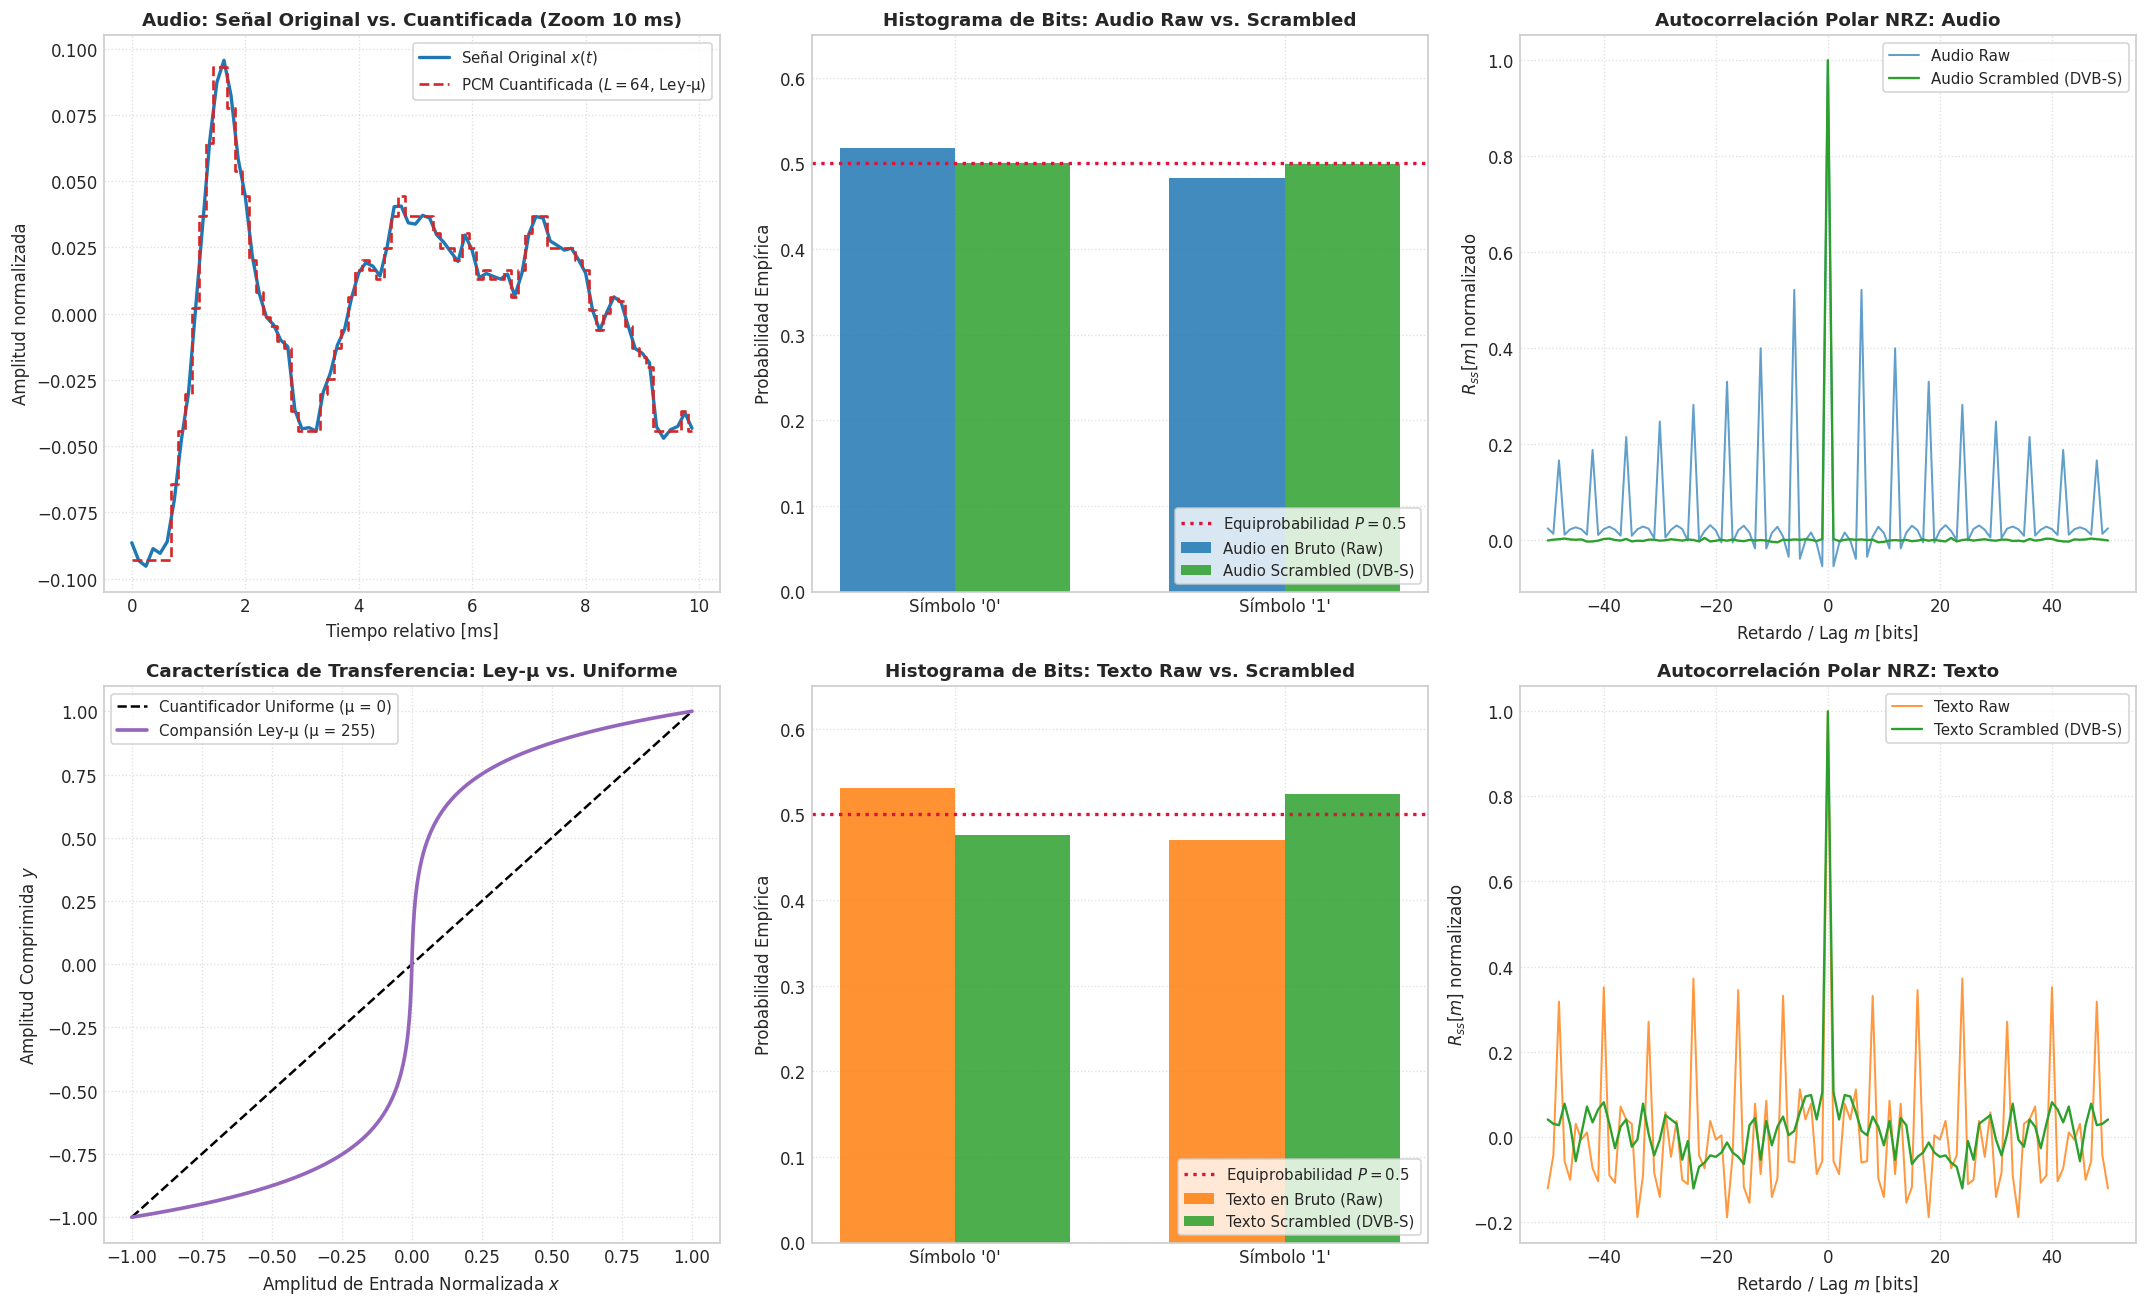

✔ Panel gráfico 2x3 generado y guardado en 'panel_laboratorio_1.png' a 300 DPI.


In [7]:
# ==============================================================================
# MÓDULO 6: PANEL DE VISUALIZACIÓN GRÁFICA COMPARATIVA (2 FILAS x 3 COLUMNAS)
# ==============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11), dpi=120)

# ------------------------------------------------------------------------------
# FILA 1, PANEL 0: AUDIO TEMPORAL (ORIGINAL VS. CUANTIFICADA PCM)
# ------------------------------------------------------------------------------
# Ubicar un segmento representativo activo de la señal (evitando silencios iniciales)
indice_activo = np.where(np.abs(audio_norm) > 0.08)[0]
inicio_zoom = indice_activo[0] if len(indice_activo) > 0 else 0
muestras_zoom = int(0.010 * fs_audio)  # 10 ms de duración (80 muestras a 8 kHz)
t_ms = (np.arange(muestras_zoom) / fs_audio) * 1000.0

axes[0, 0].plot(
    t_ms, 
    audio_norm[inicio_zoom : inicio_zoom + muestras_zoom], 
    color='#1f77b4', 
    lw=2.0, 
    label='Señal Original $x(t)$'
)
axes[0, 0].step(
    t_ms, 
    audio_cuantificado[inicio_zoom : inicio_zoom + muestras_zoom], 
    color='#d62728', 
    where='mid', 
    linestyle='--', 
    lw=1.6, 
    label=f'PCM Cuantificada ($L={L_niveles}$, Ley-µ)'
)
axes[0, 0].set_title("Audio: Señal Original vs. Cuantificada (Zoom 10 ms)", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("Tiempo relativo [ms]", fontsize=10)
axes[0, 0].set_ylabel("Amplitud normalizada", fontsize=10)
axes[0, 0].legend(loc='upper right', frameon=True, fontsize=9)
axes[0, 0].grid(True, linestyle=':', alpha=0.6)

# ------------------------------------------------------------------------------
# FILA 1, PANEL 1: HISTOGRAMA DE BITS DE AUDIO (RAW VS. SCRAMBLED)
# ------------------------------------------------------------------------------
ancho_barra = 0.35
indices_x = np.array([0, 1])

axes[0, 1].bar(
    indices_x - ancho_barra / 2, 
    [stats_audio_raw['P(0)'], stats_audio_raw['P(1)']], 
    width=ancho_barra, 
    color='#1f77b4', 
    alpha=0.85, 
    label='Audio en Bruto (Raw)'
)
axes[0, 1].bar(
    indices_x + ancho_barra / 2, 
    [stats_audio_scr['P(0)'], stats_audio_scr['P(1)']], 
    width=ancho_barra, 
    color='#2ca02c', 
    alpha=0.85, 
    label='Audio Scrambled (DVB-S)'
)
axes[0, 1].axhline(0.5, color='crimson', linestyle=':', lw=2.0, label='Equiprobabilidad $P = 0.5$')
axes[0, 1].set_title("Histograma de Bits: Audio Raw vs. Scrambled", fontsize=11, fontweight='bold')
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(["Símbolo '0'", "Símbolo '1'"], fontsize=10)
axes[0, 1].set_ylabel("Probabilidad Empírica", fontsize=10)
axes[0, 1].set_ylim(0, 0.65)
axes[0, 1].legend(loc='lower right', frameon=True, fontsize=9)
axes[0, 1].grid(True, linestyle=':', alpha=0.6)

# ------------------------------------------------------------------------------
# FILA 1, PANEL 2: AUTOCORRELACIÓN DE BITS DE AUDIO (RAW VS. SCRAMBLED)
# ------------------------------------------------------------------------------
axes[0, 2].plot(stats_audio_raw['lags'], stats_audio_raw['autocorr'], color='#1f77b4', lw=1.2, alpha=0.7, label='Audio Raw')
axes[0, 2].plot(stats_audio_scr['lags'], stats_audio_scr['autocorr'], color='#2ca02c', lw=1.4, label='Audio Scrambled (DVB-S)')
axes[0, 2].set_title("Autocorrelación Polar NRZ: Audio", fontsize=11, fontweight='bold')
axes[0, 2].set_xlabel("Retardo / Lag $m$ [bits]", fontsize=10)
axes[0, 2].set_ylabel("$R_{ss}[m]$ normalizado", fontsize=10)
axes[0, 2].legend(loc='upper right', frameon=True, fontsize=9)
axes[0, 2].grid(True, linestyle=':', alpha=0.6)

# ------------------------------------------------------------------------------
# FILA 2, PANEL 0: CURVA DE COMPRESIÓN LEY-µ VS. UNIFORME
# ------------------------------------------------------------------------------
x_curva = np.linspace(-1.0, 1.0, 600)
y_mu_curva = ley_mu_compresion(x_curva, mu=255.0)

axes[1, 0].plot(x_curva, x_curva, 'k--', lw=1.5, label='Cuantificador Uniforme (µ = 0)')
axes[1, 0].plot(x_curva, y_mu_curva, color='#9467bd', lw=2.2, label='Compansión Ley-µ (µ = 255)')
axes[1, 0].set_title("Característica de Transferencia: Ley-µ vs. Uniforme", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Amplitud de Entrada Normalizada $x$", fontsize=10)
axes[1, 0].set_ylabel("Amplitud Comprimida $y$", fontsize=10)
axes[1, 0].legend(loc='upper left', frameon=True, fontsize=9)
axes[1, 0].grid(True, linestyle=':', alpha=0.6)

# ------------------------------------------------------------------------------
# FILA 2, PANEL 1: HISTOGRAMA DE BITS DE TEXTO (RAW VS. SCRAMBLED)
# ------------------------------------------------------------------------------
axes[1, 1].bar(
    indices_x - ancho_barra / 2, 
    [stats_texto_raw['P(0)'], stats_texto_raw['P(1)']], 
    width=ancho_barra, 
    color='#ff7f0e', 
    alpha=0.85, 
    label='Texto en Bruto (Raw)'
)
axes[1, 1].bar(
    indices_x + ancho_barra / 2, 
    [stats_texto_scr['P(0)'], stats_texto_scr['P(1)']], 
    width=ancho_barra, 
    color='#2ca02c', 
    alpha=0.85, 
    label='Texto Scrambled (DVB-S)'
)
axes[1, 1].axhline(0.5, color='crimson', linestyle=':', lw=2.0, label='Equiprobabilidad $P = 0.5$')
axes[1, 1].set_title("Histograma de Bits: Texto Raw vs. Scrambled", fontsize=11, fontweight='bold')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(["Símbolo '0'", "Símbolo '1'"], fontsize=10)
axes[1, 1].set_ylabel("Probabilidad Empírica", fontsize=10)
axes[1, 1].set_ylim(0, 0.65)
axes[1, 1].legend(loc='lower right', frameon=True, fontsize=9)
axes[1, 1].grid(True, linestyle=':', alpha=0.6)

# ------------------------------------------------------------------------------
# FILA 2, PANEL 2: AUTOCORRELACIÓN DE BITS DE TEXTO (RAW VS. SCRAMBLED)
# ------------------------------------------------------------------------------
axes[1, 2].plot(stats_texto_raw['lags'], stats_texto_raw['autocorr'], color='#ff7f0e', lw=1.2, alpha=0.8, label='Texto Raw')
axes[1, 2].plot(stats_texto_scr['lags'], stats_texto_scr['autocorr'], color='#2ca02c', lw=1.4, label='Texto Scrambled (DVB-S)')
axes[1, 2].set_title("Autocorrelación Polar NRZ: Texto", fontsize=11, fontweight='bold')
axes[1, 2].set_xlabel("Retardo / Lag $m$ [bits]", fontsize=10)
axes[1, 2].set_ylabel("$R_{ss}[m]$ normalizado", fontsize=10)
axes[1, 2].legend(loc='upper right', frameon=True, fontsize=9)
axes[1, 2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
Python 3 (ipykernel)
Comunicación Digital Avanzada (UNRC)
Laboratorio N°1: Formateo de la Información y Ecualización del Histograma
Marco Normativo y Estándar Satelital: DVB-S (ETSI EN 300 421)
Contexto de Ingeniería y Objetivos

En los sistemas de comunicaciones satelitales y digitales modernos (tales como DVB-S / DVB-S2), la información proveniente de diversas fuentes (voz, telemetría, video o datos auxiliares) presenta redundancias estadísticas intrínsecas:

    Fuentes Discretas (Texto/Telemetría): Presentan una fuerte asimetría en la distribución de símbolos (en código ASCII estándar de 8 bits, el bit más significativo suele ser sistemáticamente '0', induciendo un sesgo probabilístico y periodicidades marcadas cada byte).
    Fuentes Analógicas (Voz/Audio): Muestran una distribución de amplitud fuertemente no uniforme (modelable mediante una distribución Laplaciana o Gamma), donde las pequeñas amplitudes tienen una probabilidad de ocurrencia sustancialmente mayor que los picos dinámicos.

El Desafío Físico en el Enlace Satelital

La transmisión directa de secuencias binarias no acondicionadas genera dos problemas críticos:

    Pérdida de Sincronismo de Símbolo: Largas rachas consecutivas de ceros o unos impiden la correcta recuperación de reloj (timing recovery) en el demodulador receptor (lazos de recuperación de fase y timing como Gardner o Mueller & Müller requieren transiciones frecuentes entre símbolos).
    Concentración de Densidad Espectral de Potencia (PFD): Las periodicidades de la fuente provocan líneas espectrales discretas de alta potencia. En enlaces satelitales, esto viola las normativas estrictas de la ITU-R sobre Densidad de Flujo de Potencia (Power Flux Density - PFD) en la superficie terrestre, aumentando el riesgo de interferencia perjudicial a enlaces terrenales adyacentes y causando intermodulación en el transpondedor (TWT/SSPA).

Objetivos del Laboratorio

    Formateo y Cuantificación Independiente: Procesar en paralelo, sin multiplexar, un flujo de texto (ASCII 8 bits) y un flujo de audio (8 kHz, PCM con compresión no uniforme Ley-, ).
    Caracterización de Información: Computar las probabilidades empíricas , la Entropía de Shannon , rachas consecutivas y la función de autocorrelación polar NRZ.
    Dispersión de Energía (Scrambler DVB-S): Implementar el aleatorizador PRBS basado en LFSR según la norma ETSI EN 300 421 (), verificando el aplanamiento del histograma () y la maximización de la entropía ( bit/bit).
    Descrambler y Reversibilidad Estricta: Comprobar la recuperación íntegra de ambas secuencias () y la reconstrucción fiel de las señales originales.
    Exportación Modular para Laboratorio N°2: Persistir las secuencias acondicionadas (secuencia_audio_lab1.npy y secuencia_texto_lab1.npy) junto con sus metadatos de ingeniería (metadatos_lab1.json).

# ==============================================================================
# CONFIGURACIÓN DE ENTORNO E IMPORTACIÓN DE DEPENDENCIAS
# ==============================================================================
import json
import os
from pathlib import Path
from typing import Any, Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import scipy.io.wavfile as wav
import scipy.signal as signal

# Configuración de estilo de visualización profesional para telecomunicaciones
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.autolayout'] = False

print("✔ Dependencias científicas cargadas correctamente (NumPy, SciPy, Matplotlib).")

✔ Dependencias científicas cargadas correctamente (NumPy, SciPy, Matplotlib).

Módulo 1: Formateo de Fuente Discreta (Texto / Telemetría)
Fundamento Teórico

En el estándar DVB-S, además del flujo principal de transporte (MPEG-TS), suelen transmitirse canales auxiliares de señalización, control y telemetría de red.

Una fuente discreta emite un alfabeto finito . En la codificación de caracteres estándar ASCII de 8 bits, cada carácter se mapea a un byte (octeto). Para la transmisión serial, se adopta convencionalmente el orden MSB first (Most Significant Bit first), de modo que el bit 7 (de mayor peso) precede en el tiempo al bit 0 (de menor peso).

Dado que los caracteres legibles del estándar ASCII utilizan típicamente valores en el rango decimal , el bit de mayor peso (bit 7) es sistemáticamente . Esto introduce un fuerte desbalance probabilístico inicial:
# ==============================================================================
# MÓDULO 1: FORMATEO DE FUENTE DISCRETA (TEXTO / TELEMETRÍA)
# ==============================================================================

def texto_a_bits(texto: str) -> np.ndarray:
    """Convierte una cadena de texto a un array unidimensional NumPy de bits.
    
    Aplica codificación ASCII de 8 bits por carácter con orden de transmisión
    MSB first (Most Significant Bit first).
    
    Args:
        texto: Cadena de caracteres a codificar.
        
    Returns:
        np.ndarray: Vector 1D de tipo uint8 conteniendo los bits (0s y 1s).
    """
    # Conversión a array de bytes ASCII
    bytes_data = texto.encode('ascii')
    uint8_data = np.frombuffer(bytes_data, dtype=np.uint8)
    
    # np.unpackbits descompone cada byte en 8 bits (MSB first por especificación)
    bits_array = np.unpackbits(uint8_data)
    return bits_array.astype(np.uint8)


def bits_a_texto(bits: np.ndarray) -> str:
    """Reconstruye la cadena de texto original a partir de un array de bits.
    
    Agrupa los bits de a 8 (MSB first) y decodifica la representación ASCII.
    
    Args:
        bits: Vector 1D de bits con longitud múltiplo de 8.
        
    Returns:
        str: Cadena de texto decodificada.
    """
    if len(bits) % 8 != 0:
        raise ValueError(f"La secuencia de bits debe ser múltiplo de 8 (obtenido: {len(bits)}).")
    
    # np.packbits empaqueta bloques de 8 bits en enteros uint8
    bytes_data = np.packbits(bits).tobytes()
    return bytes_data.decode('ascii')


# --- Ejecución del Módulo 1 con Mensaje de Prueba ---
mensaje_prueba = "Hola, este es un test de comunicacion"
bits_texto = texto_a_bits(mensaje_prueba)

print(f"Texto original: '{mensaje_prueba}'")
print(f"Longitud en caracteres: {len(mensaje_prueba)} caracteres")
print(f"Longitud en bits: {len(bits_texto)} bits ({len(bits_texto)//8} bytes)")
print(f"Primeros 24 bits (primeros 3 caracteres MSB-first): {bits_texto[:24]}")

# Verificación de consistencia local
texto_reconstruido_test = bits_a_texto(bits_texto)
assert mensaje_prueba == texto_reconstruido_test, "Error en la reversibilidad del codificador de texto."
print("✔ Reversibilidad local de texto verificada con éxito.")

Texto original: 'Hola, este es un test de comunicacion'
Longitud en caracteres: 37 caracteres
Longitud en bits: 296 bits (37 bytes)
Primeros 24 bits (primeros 3 caracteres MSB-first): [0 1 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 1 1 0 1 1 0 0]
✔ Reversibilidad local de texto verificada con éxito.

Módulo 2: Formateo de Fuente Analógica (Audio - Muestreo y Cuantificación PCM)
1. Teorema de Muestreo de Nyquist-Shannon

Para una señal analógica continua en tiempo de banda limitada con frecuencia máxima (ancho de banda telefónico estándar de voz), la tasa de muestreo mínima requerida para evitar aliasing espectral es:
El período de muestreo resultante es .
2. Compresión No Uniforme (Companding): Ley-

Las señales de voz y audio no poseen una distribución uniforme de amplitudes; por el contrario, presentan una distribución Laplaciana (o Gamma), donde la probabilidad acumulada de amplitudes muy bajas () es extremadamente alta, y las grandes excursiones de amplitud ocurren con poca frecuencia.

Si se utiliza una cuantificación uniforme lineal, el error relativo (y la relación señal a ruido de cuantificación, SQNR) degrada severamente para señales débiles, ya que el paso de cuantificación es constante e independiente de la amplitud instantánea.

Para contrarrestar esto, los estándares de telecomunicaciones ITU-T (como el estándar telefónico G.711) emplean compansión no uniforme. En América y Japón se adopta la Ley- ():

Donde:

    Para amplitudes pequeñas (), la pendiente es elevada:
    , aumentando fuertemente la resolución efectiva (pasos de cuantificación muy finos).
    Para amplitudes grandes (), la curva se comprime logarítmicamente.

El resultado es una relación SQNR prácticamente constante a lo largo de un rango dinámico de más de 40 dB.
3. Expansión Inversa (Reconstrucción):

4. Cuantificación Uniforme Midrise y Codificación Binaria Natural

Sobre la señal comprimida , se aplica una cuantificación en niveles midrise simétricos:
í
Cada índice entero se mapea en un código binario natural de bits (MSB first).
    
    y_q = -1.0 + (indices + 0.5) * delta
    if usar_ley_mu:
        return ley_mu_expansion(y_q, mu=mu)
    else:
        return y_q


# --- Carga de Señal de Audio con Fallback Preventivo ---
audio_path = Path("audio_lab1.wav")
fs_esperada = 8000

try:
    fs_leida, data_raw = wav.read(str(audio_path))
    print(f"✔ Archivo local '{audio_path}' cargado correctamente.")
    print(f"  Frecuencia de muestreo: {fs_leida} Hz | Formato: {data_raw.dtype} | Muestras: {len(data_raw)}")
    
    # Si la señal fuese estéreo, convertir a mono promediando canales
    if data_raw.ndim > 1:
        data_raw = data_raw.mean(axis=1)
        
    # Normalización estricta al intervalo dinámico [-1.0, 1.0]
    if np.issubdtype(data_raw.dtype, np.integer):
        max_val = np.iinfo(data_raw.dtype).max
        audio_norm = data_raw.astype(np.float64) / max_val
    else:
        audio_norm = data_raw.astype(np.float64) / np.max(np.abs(data_raw))
        
    fs_audio = fs_leida
except FileNotFoundError:
    print(f"⚠ Archivo '{audio_path}' no encontrado. Generando señal sintética multisinusoidal de prueba...")
    fs_audio = fs_esperada
    duracion_s = 0.5
    t_synth = np.linspace(0, duracion_s, int(fs_audio * duracion_s), endpoint=False)
    # Suma de componentes armónicas representativas de formantes de voz (300 Hz, 1 kHz, 2.5 kHz)
    synth_signal = (
        0.50 * np.sin(2 * np.pi * 300 * t_synth) +
        0.35 * np.sin(2 * np.pi * 1000 * t_synth) +
        0.15 * np.sin(2 * np.pi * 2500 * t_synth)
    )
    audio_norm = synth_signal / np.max(np.abs(synth_signal))
    print("✔ Señal sintética de audio generada exitosamente.")

# --- Configuración del Cuantificador PCM ---
k_bits_pcm = 6  # Configurable: ensayable con k=4 (L=16), k=6 (L=64), k=8 (L=256)
L_niveles = 2 ** k_bits_pcm
usar_compandor_mu = True

bits_audio, audio_cuantificado, delta_pcm = cuantificar_pcm(
    audio_norm, 
    k_bits=k_bits_pcm, 
    usar_ley_mu=usar_compandor_mu, 
    mu=255.0
)

# Cálculo de la Relación Señal a Ruido de Cuantificación (SQNR)
ruido_cuantificacion = audio_norm - audio_cuantificado
potencia_senal = np.mean(audio_norm ** 2)
potencia_ruido = np.mean(ruido_cuantificacion ** 2)
sqnr_db = 10 * np.log10(potencia_senal / potencia_ruido) if potencia_ruido > 0 else float('inf')

print(f"Parámetros de Cuantificación PCM:")
print(f"  Resolución: k = {k_bits_pcm} bits/muestra -> L = {L_niveles} niveles.")
print(f"  Paso de cuantificación (dominio comprimido): Δ = {delta_pcm:.5f}")
print(f"  Compansión: Ley-µ (µ = 255.0) -> {'ACTIVADA' if usar_compandor_mu else 'DESACTIVADA'}")
print(f"  Longitud del flujo binario resultante: {len(bits_audio)} bits")
print(f"  SQNR Empírico medido: {sqnr_db:.2f} dB")

✔ Archivo local 'audio_lab1.wav' cargado correctamente.
  Frecuencia de muestreo: 8000 Hz | Formato: int16 | Muestras: 50573
Parámetros de Cuantificación PCM:
  Resolución: k = 6 bits/muestra -> L = 64 niveles.
  Paso de cuantificación (dominio comprimido): Δ = 0.03125
  Compansión: Ley-µ (µ = 255.0) -> ACTIVADA
  Longitud del flujo binario resultante: 303438 bits
  SQNR Empírico medido: 25.90 dB

Módulo 3: Caracterización Estadística Base (Función Universal)
1. Entropía de Shannon

La entropía de una fuente binaria sin memoria modelada por la variable aleatoria mide el contenido medio de información o incertidumbre en bit/bit:

    La entropía es máxima ( bit/bit) si y solo si la fuente es equiprobable: .
    Si la fuente presenta sesgo (), la entropía es estrictamente menor a 1, indicando la existencia de redundancia estadística compresible y predecible.

2. Rachas Máximas Consecutivas (Run Length)

Una racha (consecutive run) es una secuencia ininterrumpida de símbolos idénticos ( o ).

    En demoduladores coherentes, el sincronismo de símbolo depende de las transiciones de cruce por cero de la señal banda base.
    Rachas prolongadas de ceros o unos provocan que los filtros de lazo de recuperación de portadora y timing pierdan seguimiento, incrementando el jitter de fase y la probabilidad de error de bit (BER).

3. Función de Autocorrelación Normalizada Polar NRZ

Para analizar la memoria temporal y las periodicidades ocultas de la secuencia de bits , se mapea a una señal binaria antipodal polar NRZ:
La función de autocorrelación determinística para un retardo (lag) se define como:

    Para , (potencia media normalizada).
    Para secuencias de datos altamente correlacionadas (como caracteres de texto o muestras de audio), presenta lóbulos y picos secundarios significativos para retardos .
    Una fuente aleatoria pura (blanca) o idealmente ecualizada presenta:

# ==============================================================================
    
    # Autocorrelación vía algoritmo FFT O(N log N)
    corr_full = signal.correlate(s_nrz, s_nrz, mode='full', method='fft')
    lags_full = signal.correlation_lags(N, N, mode='full')
    
    # Normalización tal que R_ss[0] = 1.0
    corr_norm = corr_full / N
    
    # Ventana de retardos relevantes
    mascara = (lags_full >= -max_lags) & (lags_full <= max_lags)
    return lags_full[mascara], corr_norm[mascara]


def evaluar_estadisticas(bitstream: np.ndarray, nombre_fuente: str = "Bitstream") -> Dict[str, Any]:
    """Evalúa integralmente las propiedades estadísticas y de información de un flujo binario.
    
    Args:
        bitstream: Array 1D de bits a evaluar.
        nombre_fuente: Etiqueta descriptiva para reporte.
        
    Returns:
        Dict[str, Any]: Diccionario con métricas empíricas calculadas.
    """
    N = len(bitstream)
    if N == 0:
        raise ValueError("El bitstream no puede ser de longitud cero.")
        
    n_ceros = int(np.sum(bitstream == 0))
    n_unos = int(np.sum(bitstream == 1))
    p0 = n_ceros / N
    p1 = n_unos / N
    
    # Entropía de Shannon H(X) en bit/bit
    h0 = -p0 * np.log2(p0) if p0 > 0 else 0.0
    h1 = -p1 * np.log2(p1) if p1 > 0 else 0.0
    H = h0 + h1
    
    racha_0 = calcular_racha_maxima(bitstream, 0)
    racha_1 = calcular_racha_maxima(bitstream, 1)
    
    lags, autocorr = calcular_autocorrelacion_nrz(bitstream, max_lags=50)
    
    resultado = {
        "fuente": nombre_fuente,
        "N_bits": N,
        "P(0)": p0,
        "P(1)": p1,
        "H(X)": H,
        "racha_max_0": racha_0,
        "racha_max_1": racha_1,
        "lags": lags,
        "autocorr": autocorr
    }
    return resultado


# --- Evaluación Estadística en Bruto de Ambas Fuentes ---
stats_texto_raw = evaluar_estadisticas(bits_texto, "Texto (Raw)")
stats_audio_raw = evaluar_estadisticas(bits_audio, "Audio PCM (Raw)")

print("=" * 70)
print("CARACTERIZACIÓN ESTADÍSTICA DE FUENTES EN BRUTO (PRE-SCRAMBLER)")
print("=" * 70)
for st in [stats_texto_raw, stats_audio_raw]:
    print(f"Fuente: {st['fuente']}")
    print(f"  Longitud: {st['N_bits']} bits")
    print(f"  P(0): {st['P(0)']:.5f} | P(1): {st['P(1)']:.5f}")
    print(f"  Entropía H(X): {st['H(X)']:.5f} bit/bit (Máximo teórico: 1.0)")
    print(f"  Racha máxima ceros: {st['racha_max_0']} bits | Racha máxima unos: {st['racha_max_1']} bits")
    print("-" * 70)

======================================================================
CARACTERIZACIÓN ESTADÍSTICA DE FUENTES EN BRUTO (PRE-SCRAMBLER)
======================================================================
Fuente: Texto (Raw)
  Longitud: 296 bits
  P(0): 0.53041 | P(1): 0.46959
  Entropía H(X): 0.99733 bit/bit (Máximo teórico: 1.0)
  Racha máxima ceros: 6 bits | Racha máxima unos: 4 bits
----------------------------------------------------------------------
Fuente: Audio PCM (Raw)
  Longitud: 303438 bits
  P(0): 0.51752 | P(1): 0.48248
  Entropía H(X): 0.99911 bit/bit (Máximo teórico: 1.0)
  Racha máxima ceros: 7 bits | Racha máxima unos: 7 bits
----------------------------------------------------------------------

Módulo 4: Acondicionamiento Estadístico / Scrambler LFSR (Norma DVB-S)
1. Especificación Normativa ETSI EN 300 421

El estándar europeo de radiodifusión de televisión y datos por satélite DVB-S especifica en su sección de Energy Dispersal (Dispersión de Energía) que el flujo binario debe ser aleatorizado mediante una Secuencia Binaria Pseudoaleatoria (PRBS) generada por un registro de desplazamiento con realimentación lineal (LFSR).
2. Polinomio Generador Primitivo y Semilla de Carga

    Polinomio Generador: Polinomio primitivo de orden 15:
    Registro LFSR: Compuesto por 15 etapas ( a ).
    Ecuación de Realimentación: El bit que ingresa a la primera etapa () en cada pulso de reloj es la suma módulo-2 (XOR) de las salidas de las etapas 14 y 15:
    El bit PRBS de salida resultante que se combina con el flujo de información es precisamente .
    Vector de Inicialización Oficial (Semilla):
    ó
    Período Máximo: Al ser un polinomio primitivo, la secuencia generada es una secuencia de longitud máxima (-sequence) con período:

3. Dispersión de Energía y Operación XOR

La secuencia aleatorizada se obtiene mediante la suma módulo-2 bit a bit:
Donde es el bitstream de la fuente y es la secuencia PRBS generada. Esta operación garantiza:

    Aplanamiento del Histograma: .
    Supresión de Líneas Espectrales: El espectro de la señal modulada se vuelve cuasi-gaussiano y continuo, satisfaciendo los límites de PFD de la ITU-R.
    Mantenimiento del Sincronismo: Se garantiza una densidad controlada de transiciones entre niveles lógicos para el demodulador.

# ==============================================================================
# MÓDULO 4: ACONDICIONAMIENTO ESTADÍSTICO / SCRAMBLER LFSR (NORMA DVB-S)
# ==============================================================================

# Semilla de inicialización oficial de la norma ETSI EN 300 421 (15 bits)
SEMILLA_DVB_S: List[int] = [1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0]


def generar_secuencia_pn(longitud: int, semilla: List[int] = SEMILLA_DVB_S) -> np.ndarray:
    """Genera la secuencia pseudoaleatoria PRBS según la norma DVB-S (ETSI EN 300 421).
    
    Implementa el LFSR de 15 etapas con polinomio P(x) = 1 + X^14 + X^15.
    Período máximo: 2^15 - 1 = 32767 bits. Se repite periódicamente según la longitud requerida.
    
    Args:
        longitud: Cantidad de bits PRBS a generar.
        semilla: Vector inicial de 15 bits [D1, D2, ..., D15].
        
    Returns:
        np.ndarray: Vector 1D de tipo uint8 con la secuencia PRBS generada.
    """
    if len(semilla) != 15:
        raise ValueError(f"La semilla DVB-S debe poseer exactamente 15 bits (recibido: {len(semilla)}).")
        
    reg = list(semilla)
    pn_seq = np.empty(longitud, dtype=np.uint8)
    
    for i in range(longitud):
        # Etapas D14 y D15 (índices 13 y 14 en base cero)
        feedback = reg[13] ^ reg[14]
        pn_seq[i] = feedback
        
        # Desplazamiento del registro a la derecha: reg[0] recibe el feedback
        reg = [feedback] + reg[:-1]
        
    return pn_seq


def scrambler_dvb(bitstream: np.ndarray, semilla: List[int] = SEMILLA_DVB_S) -> np.ndarray:
    """Aplica aleatorización DVB-S mediante suma módulo-2 (XOR) con la secuencia PRBS."""
    pn = generar_secuencia_pn(len(bitstream), semilla)
    return (bitstream ^ pn).astype(np.uint8)


# --- Aplicación del Scrambler por separado sobre Texto y Audio ---
bits_texto_scrambled = scrambler_dvb(bits_texto, SEMILLA_DVB_S)
bits_audio_scrambled = scrambler_dvb(bits_audio, SEMILLA_DVB_S)

# Reevaluación de estadísticas post-scrambler
stats_texto_scr = evaluar_estadisticas(bits_texto_scrambled, "Texto (Scrambled DVB-S)")
stats_audio_scr = evaluar_estadisticas(bits_audio_scrambled, "Audio (Scrambled DVB-S)")

print("=" * 70)
print("CARACTERIZACIÓN ESTADÍSTICA POST-SCRAMBLER DVB-S")
print("=" * 70)
for st in [stats_texto_scr, stats_audio_scr]:
    print(f"Fuente: {st['fuente']}")
    print(f"  Longitud: {st['N_bits']} bits")
    print(f"  P(0): {st['P(0)']:.5f} | P(1): {st['P(1)']:.5f}")
    print(f"  Entropía H(X): {st['H(X)']:.5f} bit/bit")
    print(f"  Racha máxima ceros: {st['racha_max_0']} bits | Racha máxima unos: {st['racha_max_1']} bits")
    print("-" * 70)

======================================================================
CARACTERIZACIÓN ESTADÍSTICA POST-SCRAMBLER DVB-S
======================================================================
Fuente: Texto (Scrambled DVB-S)
  Longitud: 296 bits
  P(0): 0.47635 | P(1): 0.52365
  Entropía H(X): 0.99839 bit/bit
  Racha máxima ceros: 10 bits | Racha máxima unos: 9 bits
----------------------------------------------------------------------
Fuente: Audio (Scrambled DVB-S)
  Longitud: 303438 bits
  P(0): 0.50048 | P(1): 0.49952
  Entropía H(X): 1.00000 bit/bit
  Racha máxima ceros: 18 bits | Racha máxima unos: 17 bits
----------------------------------------------------------------------

Módulo 5: Descrambler y Verificación de Reversibilidad Estricta ()
Fundamento Matemático del Descrambler

La operación XOR es un operador autoinverso en el cuerpo de Galois de dos elementos . Dado el bitstream transmitido , si en el receptor se genera una secuencia PRBS idéntica e intrínsecamente sincronizada con la del transmisor (misma semilla y mismo instante de inicialización):

Por lo tanto:

    El circuito descrambler es idéntico al circuito scrambler (auto-involutivo).
    En ausencia de ruido o errores de canal, la tasa de error de bit (BER) debe ser idénticamente cero:

# ==============================================================================
# MÓDULO 5: DESCRAMBLER Y VERIFICACIÓN DE REVERSIBILIDAD (BER = 0)
# ==============================================================================

def descrambler_dvb(bitstream_scrambled: np.ndarray, semilla: List[int] = SEMILLA_DVB_S) -> np.ndarray:
    """Descrambler DVB-S: operación inversa sincronizada (XOR idéntico con la PRBS)."""
    return scrambler_dvb(bitstream_scrambled, semilla)


# --- Recuperación de Flujos Binarios en Recepción ---
bits_texto_rx = descrambler_dvb(bits_texto_scrambled, SEMILLA_DVB_S)
bits_audio_rx = descrambler_dvb(bits_audio_scrambled, SEMILLA_DVB_S)

# Cálculo de Bit Error Rate (BER)
errores_texto = int(np.sum(bits_texto_rx != bits_texto))
ber_texto = errores_texto / len(bits_texto)

errores_audio = int(np.sum(bits_audio_rx != bits_audio))
ber_audio = errores_audio / len(bits_audio)

# --- Comprobación Estricta con Assertions ---
assert np.array_equal(bits_texto_rx, bits_texto), "Falla crítica: BER de Texto > 0"
assert np.array_equal(bits_audio_rx, bits_audio), "Falla crítica: BER de Audio > 0"

# Reconstrucción de la información de usuario
texto_recuperado = bits_a_texto(bits_texto_rx)
audio_recuperado = decodificar_pcm(bits_audio_rx, k_bits=k_bits_pcm, usar_ley_mu=usar_compandor_mu, mu=255.0)

# Verificación de fidelidad de audio
error_reconstruccion_audio = np.max(np.abs(audio_cuantificado - audio_recuperado))
assert error_reconstruccion_audio < 1e-12, "Falla en la reconstrucción analógica de audio."

print("=" * 70)
print("VERIFICACIÓN DE REVERSIBILIDAD Y FIDELIDAD EN RECEPCIÓN")
print("=" * 70)
print(f"✔ BER Canal Texto: {ber_texto:.8f} (Errores: {errores_texto} / {len(bits_texto)} bits)")
print(f"✔ Texto Recuperado: '{texto_recuperado}'")
print(f"✔ BER Canal Audio: {ber_audio:.8f} (Errores: {errores_audio} / {len(bits_audio)} bits)")
print(f"✔ Reconstrucción Analógica de Audio verificada (Error numérico: {error_reconstruccion_audio:.2e})")
print("=" * 70)

======================================================================
VERIFICACIÓN DE REVERSIBILIDAD Y FIDELIDAD EN RECEPCIÓN
======================================================================
✔ BER Canal Texto: 0.00000000 (Errores: 0 / 296 bits)
✔ Texto Recuperado: 'Hola, este es un test de comunicacion'
✔ BER Canal Audio: 0.00000000 (Errores: 0 / 303438 bits)
✔ Reconstrucción Analógica de Audio verificada (Error numérico: 0.00e+00)
======================================================================

Módulo 6: Panel de Visualización Gráfica (Subplots Comparativos)

Para comprender el impacto del acondicionamiento satelital y el formateo digital, se construye una figura estructurada en una grilla de 2 filas 3 columnas:

    Fila 1 (Fuente Analógica - Audio):
        Subplot (0, 0): Señal original continua vs. señal cuantificada PCM: Detalla el seguimiento temporal de la forma de onda acústica en un intervalo de 10 ms (zoom a una ventana activa de habla), evidenciando los escalones discretos midrise y la fidelidad introducida por la cuantificación de 6 bits ().
        Subplot (0, 1): Histograma de bits de Audio (Raw vs. Scrambled): Demuestra el centrado exacto sobre la línea teórica de equiprobabilidad post-scrambling.
        Subplot (0, 2): Autocorrelación Polar NRZ de Audio: Revela la drástica transformación desde una secuencia con periodicidades armónicas de muestreo y entonación vocal a una función delta ideal .

    Fila 2 (Fuente Discreta - Texto y Ley-):
        Subplot (1, 0): Característica de Compresión Ley- () vs. Uniforme: Visualiza la pendiente amplificada en el origen frente a la identidad lineal, justificando la mayor resolución en pequeñas amplitudes.
        Subplot (1, 1): Histograma de bits de Texto (Raw vs. Scrambled): Muestra la eliminación del sesgo introducido por el byte ASCII (donde el bit 7 es sistemáticamente 0).
        Subplot (1, 2): Autocorrelación Polar NRZ de Texto: Expone cómo los picos periódicos cada 8 bits (ritmo de byte) desaparecen por completo, aplanando la densidad espectral de potencia y suprimiendo líneas espectrales discretas.

# ==============================================================================
axes[0, 2].set_xlabel("Retardo / Lag $m$ [bits]", fontsize=10)
axes[0, 2].set_ylabel("$R_{ss}[m]$ normalizado", fontsize=10)
axes[0, 2].legend(loc='upper right', frameon=True, fontsize=9)
axes[0, 2].grid(True, linestyle=':', alpha=0.6)

# ------------------------------------------------------------------------------
# FILA 2, PANEL 0: CURVA DE COMPRESIÓN LEY-µ VS. UNIFORME
# ------------------------------------------------------------------------------
x_curva = np.linspace(-1.0, 1.0, 600)
y_mu_curva = ley_mu_compresion(x_curva, mu=255.0)

axes[1, 0].plot(x_curva, x_curva, 'k--', lw=1.5, label='Cuantificador Uniforme (µ = 0)')
axes[1, 0].plot(x_curva, y_mu_curva, color='#9467bd', lw=2.2, label='Compansión Ley-µ (µ = 255)')
axes[1, 0].set_title("Característica de Transferencia: Ley-µ vs. Uniforme", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Amplitud de Entrada Normalizada $x$", fontsize=10)
axes[1, 0].set_ylabel("Amplitud Comprimida $y$", fontsize=10)
axes[1, 0].legend(loc='upper left', frameon=True, fontsize=9)
axes[1, 0].grid(True, linestyle=':', alpha=0.6)

# ------------------------------------------------------------------------------
# FILA 2, PANEL 1: HISTOGRAMA DE BITS DE TEXTO (RAW VS. SCRAMBLED)
# ------------------------------------------------------------------------------
axes[1, 1].bar(
    indices_x - ancho_barra / 2, 
    [stats_texto_raw['P(0)'], stats_texto_raw['P(1)']], 
    width=ancho_barra, 
    color='#ff7f0e', 
    alpha=0.85, 
    label='Texto en Bruto (Raw)'
)
axes[1, 1].bar(
    indices_x + ancho_barra / 2, 
    [stats_texto_scr['P(0)'], stats_texto_scr['P(1)']], 
    width=ancho_barra, 
    color='#2ca02c', 
    alpha=0.85, 
    label='Texto Scrambled (DVB-S)'
)
axes[1, 1].axhline(0.5, color='crimson', linestyle=':', lw=2.0, label='Equiprobabilidad $P = 0.5$')
axes[1, 1].set_title("Histograma de Bits: Texto Raw vs. Scrambled", fontsize=11, fontweight='bold')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(["Símbolo '0'", "Símbolo '1'"], fontsize=10)
axes[1, 1].set_ylabel("Probabilidad Empírica", fontsize=10)
axes[1, 1].set_ylim(0, 0.65)
axes[1, 1].legend(loc='lower right', frameon=True, fontsize=9)
axes[1, 1].grid(True, linestyle=':', alpha=0.6)

# ------------------------------------------------------------------------------
# FILA 2, PANEL 2: AUTOCORRELACIÓN DE BITS DE TEXTO (RAW VS. SCRAMBLED)
# ------------------------------------------------------------------------------
axes[1, 2].plot(stats_texto_raw['lags'], stats_texto_raw['autocorr'], color='#ff7f0e', lw=1.2, alpha=0.8, label='Texto Raw')
axes[1, 2].plot(stats_texto_scr['lags'], stats_texto_scr['autocorr'], color='#2ca02c', lw=1.4, label='Texto Scrambled (DVB-S)')
axes[1, 2].set_title("Autocorrelación Polar NRZ: Texto", fontsize=11, fontweight='bold')
axes[1, 2].set_xlabel("Retardo / Lag $m$ [bits]", fontsize=10)
axes[1, 2].set_ylabel("$R_{ss}[m]$ normalizado", fontsize=10)
axes[1, 2].legend(loc='upper right', frameon=True, fontsize=9)
axes[1, 2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig("panel_laboratorio_1.png", dpi=300, bbox_inches='tight')
plt.show()
print("✔ Panel gráfico 2x3 generado y guardado en 'panel_laboratorio_1.png' a 300 DPI.")

plt.savefig("panel_laboratorio_1.png", dpi=300, bbox_inches='tight')
plt.show()
print("✔ Panel gráfico 2x3 generado y guardado en 'panel_laboratorio_1.png' a 300 DPI.")

---
### Módulo 7: Exportación de Secuencias para el Laboratorio N°2 y Tabla Comparativa

#### Interfaz con el Modulador Digital (Laboratorio N°2)
En la arquitectura del transmisor digital DVB-S, el flujo de bits acondicionado tras la dispersión de energía constituye la entrada física del codificador de canal externo (FEC Reed-Solomon / Convolucional) y posterior modulador digital (**QPSK / 8-PSK**).

Para garantizar la portabilidad y la alimentación directa de los módulos subsecuentes, se persisten las secuencias binarias acondicionadas como arrays NumPy (`.npy`) y un archivo JSON (`metadatos_lab1.json`) con los descriptores de ingeniería requeridos.

In [8]:
# ==============================================================================
# MÓDULO 7: EXPORTACIÓN PARA EL LABORATORIO N°2 Y TABLA COMPARATIVA
# ==============================================================================

# 1. Guardado de secuencias binarias acondicionadas en formato NumPy (.npy)
archivo_audio_npy = "secuencia_audio_lab1.npy"
archivo_texto_npy = "secuencia_texto_lab1.npy"

np.save(archivo_audio_npy, bits_audio_scrambled)
np.save(archivo_texto_npy, bits_texto_scrambled)

print(f"✔ Secuencia de audio exportada: '{archivo_audio_npy}' ({len(bits_audio_scrambled)} bits)")
print(f"✔ Secuencia de texto exportada: '{archivo_texto_npy}' ({len(bits_texto_scrambled)} bits)")

# 2. Generación y exportación de archivo de metadatos JSON
metadatos = {
    "laboratorio": "Laboratorio N°1: Formateo de Información y Ecualización del Histograma",
    "estandar": "DVB-S (ETSI EN 300 421)",
    "polinomio_prbs": "1 + X^14 + X^15",
    "semilla_dvb_s": SEMILLA_DVB_S,
    "fuente_discreta_texto": {
        "archivo_salida": archivo_texto_npy,
        "longitud_bits": int(len(bits_texto_scrambled)),
        "codificacion": "ASCII 8-bit MSB-first",
        "mensaje_origen": mensaje_prueba,
        "H_raw": float(stats_texto_raw['H(X)']),
        "H_scrambled": float(stats_texto_scr['H(X)'])
    },
    "fuente_analogica_audio": {
        "archivo_salida": archivo_audio_npy,
        "longitud_bits": int(len(bits_audio_scrambled)),
        "frecuencia_muestreo_hz": int(fs_audio),
        "bits_por_muestra_k": int(k_bits_pcm),
        "niveles_cuantificacion_L": int(L_niveles),
        "compansion": "Ley-µ (µ = 255.0)",
        "sqnr_db": float(sqnr_db),
        "H_raw": float(stats_audio_raw['H(X)']),
        "H_scrambled": float(stats_audio_scr['H(X)'])
    }
}

archivo_metadatos = "metadatos_lab1.json"
with open(archivo_metadatos, "w", encoding="utf-8") as f:
    json.dump(metadatos, f, indent=4, ensure_ascii=False)

print(f"✔ Archivo de metadatos exportado: '{archivo_metadatos}'")

# 3. Tabla Comparativa Final de Métricas Estadísticas
print("\n" + "=" * 84)
print(f"{'TABLA COMPARATIVA FINAL: IMPACTO DEL ACONDICIONAMIENTO DVB-S':^84}")
print("=" * 84)
encabezado = f"{'Fuente / Estado':<28} | {'P(0)':^8} | {'P(1)':^8} | {'H(X) [bit]':^12} | {'Racha 0':^8} | {'Racha 1':^8}"
print(encabezado)
print("-" * 84)

filas_tabla = [
    (stats_texto_raw['fuente'], stats_texto_raw),
    (stats_texto_scr['fuente'], stats_texto_scr),
    (stats_audio_raw['fuente'], stats_audio_raw),
    (stats_audio_scr['fuente'], stats_audio_scr)
]

for nombre, st in filas_tabla:
    fila_str = f"{nombre:<28} | {st['P(0)']:^8.4f} | {st['P(1)']:^8.4f} | {st['H(X)']:^12.4f} | {st['racha_max_0']:^8d} | {st['racha_max_1']:^8d}"
    print(fila_str)

print("=" * 84)
print("Conclusión: El aleatorizador DVB-S logra maximizar la entropía empírica H(X) -> 1.0,")
print("equiprobabiliza los símbolos (P(0) ≈ P(1) ≈ 0.5) y dispersa la energía espectral,")
print("eliminando armónicos de periodicidad y asegurando reversibilidad estricta (BER = 0).")
print("=" * 84)

✔ Secuencia de audio exportada: 'secuencia_audio_lab1.npy' (303438 bits)
✔ Secuencia de texto exportada: 'secuencia_texto_lab1.npy' (296 bits)
✔ Archivo de metadatos exportado: 'metadatos_lab1.json'

            TABLA COMPARATIVA FINAL: IMPACTO DEL ACONDICIONAMIENTO DVB-S            
Fuente / Estado              |   P(0)   |   P(1)   |  H(X) [bit]  | Racha 0  | Racha 1 
------------------------------------------------------------------------------------
Texto (Raw)                  |  0.5304  |  0.4696  |    0.9973    |    6     |    4    
Texto (Scrambled DVB-S)      |  0.4764  |  0.5236  |    0.9984    |    10    |    9    
Audio PCM (Raw)              |  0.5175  |  0.4825  |    0.9991    |    7     |    7    
Audio (Scrambled DVB-S)      |  0.5005  |  0.4995  |    1.0000    |    18    |    17   
Conclusión: El aleatorizador DVB-S logra maximizar la entropía empírica H(X) -> 1.0,
equiprobabiliza los símbolos (P(0) ≈ P(1) ≈ 0.5) y dispersa la energía espectral,
eliminando armónicos de